# LAB 1 -- DAY 3B -- Case 1 t-test

How do we know if we get the right answer? Let's say the right answer is 7.6 g and you obtained a value of 8.1 g. Is that the right answer? What if you got a value of 8.1 g $\pm$ 0.4 g?

One way to determine if your answer is "correct" is by using a confidence interval (CI), with an equation given by:

$$\bar{x} \pm \frac{t_{table} s} {\sqrt{n}}$$

Don't worry, we'll break down this equation later.

If your answer falls within the lower and upper bounds, then we can be confident that it *is* the right answer.

In the example above, 8.1 $\pm$ 0.4 creates a CI of (7.7, 8.5) where the lower end = 7.7 and the upper end = 8.5. Any value below the lower end or above the upper end is not included. We got an answer of 7.6, which is not within the confidence interval. Therefore, we can not be confident that the answer we got is the right answer.

In this notebook, we are going to calculate and determine if the confidence interval includes the "right answer".

To do this, we will:
1. Upload and read the data file to get the data list and right answer.
2. Calculate the confidence interval.
3. Determine if the right answer is included in the CI.

## First step: importing and reading the CSV (data) file

Just like the previous parts, you will upload the correct CSV file, "case1.csv".

In [ ]:
# importing a file from your computer
# using one of google colab's libraries
from google.colab import files

# files.upload() opens a file picker so you can upload a (CSV) file from your computer
# the uploaded file is stored in the Colab session so Python can read the data inside it
# note: you only have to upload once. after that, it should save the file and you can press "cancel upload" to skip this step
# in the case it doesn't save the file, then just reupload.
uploaded = files.upload()

# TODO [+1 pt]
# 1) click run -> choose files -> select 'case1.csv' [+1 pt]

# after it uploads successfully, continue running the remaining cells

Saving case1.csv to case1.csv


## Where do we find the right answer??

The CSV file that we are uploading is a little different than the ones before. In this case, the last value in the column contains the known or correct value ("right answer").

This is an example of what the data file will look like:

```
1
2
3


4
```

Here, '4' is the right answer we are given and [1, 2, 3] are the values that will be in data_list.

In order to do this, we can loop through each row, ignoring the rows that are empty (denoted by an empty string: ""), and add each value into data_list. Then, outside of the for loop near the end, we know the last value is the right answer, so we can put that into right_answer. Finally, we remove that value from data_list since it is not one of the experimental measurements and we only want the measurements in data_list when calculating statistics like the average and standard deviation.

This is done with code:
```
      # here, we are checking that the row is NOT empty by using != (not equal)
      # and comparing row[0] (the current row of data) to an empty string ("").
      if row[0] != "":            
```

```
# here, we get right_answer by accessing the last item in data_list
# and then popping that value from data_list
right_answer = data_list[-1]  # index = -1 is a quick way to access the LAST value in a list
data_list.pop()               # removes LAST item in list, can also be done with: data_list.remove(right_answer)
```




In [1]:
# 1. importing csv so we can read our file
import csv

# 2. creating a data_list to store our values
data_list = []

# 3. reading the file line by line and adding each value to data list
# note: if this doesn't work, check the file name is correct. feel free to update if needed
with open("case1.csv", "r") as f:   # opening "case1.csv" in read mode using f to call our file

  # 4. uses csv library to read our file f and put into variable called data
  data = csv.reader(f)

  # 5. we are looping through each row in our data.
  for row in data:

    # 6. making sure row is not empty
    if row and row[0] != "":

      # 7. adding the data (row[0]) into our data list

      # TODO [+1 pt]
      # 1) delete 'pass', convert to float and add data to data_list [+1 pt]
      pass


# 8. putting last item of data_list into right_answer and then removing that value from list
right_answer = data_list[-1]
data_list.pop()

# printing data_list and right_answer
# make sure data_list has 9 values !!
print(f"data_list = {data_list} \nlength of data_list = {len(data_list)}")
print(f"right_answer = {right_answer}")

FileNotFoundError: [Errno 2] No such file or directory: 'case1.csv'

## Now, to find the Confidence Interval (CI)

The confidence interval is given by:

$$\bar{x} \pm \frac{t_{table} s} {\sqrt{n}}$$

where:
* $\bar{x}$ = average
* $t_{table}$ = a number we will calculate (usually comes from a table based on the normal distribution)
* $s$ = sample standard deviation
* $n$ = number of measurements

The $\pm$ symbol means we calculate two values:
* subtract (-) to find the lower end
* add (+) to find the upper end

This will result in (lower_end, upper_end) and we will use this to later determine if the right answer fits inside this interval.

To do this, we need the stats functions we used in previous notebooks plus a new one for finding t_table.

Make sure to run the functions below!!

In [ ]:
# @title average(data_list)
def average(data_list):
  sum = 0                       # init sum to 0
  data_length = len(data_list)  # find number of values in list

  # sum up each value in data_list
  for i in range(data_length):
    sum += data_list[i]         # sum = sum + data_list[i]

  # find the average of the data list
  average = sum / data_length

  # returns average
  return average

In [ ]:
# @title sample_sd(data_list)
import math                         # to take square root

def sample_sd(data_list):
  sum_of_deviances = 0              # initialize sum to 0
  data_length = len(data_list)      # find length of data

  # calculate average
  avg = average(data_list)          # use function we made to find average

  # find deviations from mean for each data point
  for i in range(data_length):
    deviation = data_list[i] - avg  # subract mean from each data point
    squared_d = (deviation ** 2)    # square the deviation to ensure all positive values
    sum_of_deviances += squared_d   # sum all squared deviations

  # divide sum by (n-1) where n is the data_length
  variance = sum_of_deviances / (data_length - 1)

  # take square root to give sample standard deviation and return it
  sample_sd = math.sqrt(variance)
  return sample_sd

In [ ]:
# @title t_inv_2t(sig_val, dof)
# imports to access stats t functions
from scipy.stats import t

def t_inv_2t(sig_val, dof):
  sig_val = sig_val / 2
  return float(t.ppf(1-sig_val, df=dof))

## Use these functions to find the confidence interval variables

* **average(data_list)** --> returns average of data_list
* **sample_sd(data_list)** --> returns sample standard deviation of data_list
* **len(data_list)** --> returns the length of the data_list, one of python's built-in functions
* **t_inv_2t(sig_val, dof)** --> returns t_table value where sig_val = 0.05 and dof = n - 1


In [ ]:
# calculate variables inside CI eq

# TODO FOR STUDENTS [+4 pts]
# 1) find x_bar [+1 pt]
x_bar = None
# 2) find s [+1 pt]
s = None
# 3) find n [+1 pt]
n = None
# 4) find t_table [+1 pt]
t_table = None

# printing values
print(f"x_bar = {x_bar}")
print(f"s = {s}")
print(f"n = {n}")
print(f"t_table = {t_table}")

## Now, let's calculate the CI

Find the lower and upper limits using the equation:

$$\bar{x} \pm \frac{t_{table} s} {\sqrt{n}}$$

Remember:
* every multiplication must include '*' since python doesn't assume multiplication automatically and gives an error without it
* use math.sqrt(value) to take the square root of a value
* make sure to use () when appropriate to preserve correct order of operations

In [ ]:
# calulcate the CI
# use the CI equation with variables created above

# TODO [+2 pts]
# 1) find the lower end (-) [+2 pts]
lower_end = None

# TODO [+2 pts]
# 1) find the upper end (+) [+2 pts]
upper_end = None

# printing values
print(f"lower_end = {lower_end}")
print(f"higher_end = {upper_end}")

## Is the right answer included in the CI ??

First, we are going to print the CI and right answer. Then, we determine whether the answer is included using a Boolean expression.

Boolean values have only two possible outputs: **True** or **False**. They are commonly used to answer yes/no questions and are especially useful in conditionals.

Think of:
* True as On or Yes
* False as Off or No

For example:

```
grade = 69

passed = grade >= 60        # conditional, checking if grade (69) is greater than or equal (>=) to 60
print(passed)               # output: True

is_b = 80 <= grade < 90     # checks if grade is between an 80 and 90 to get a letter grade of B
print(is_b)                 # output: False
```

Note: capitalization matters in Python. True and False are Boolean values, while true and false (lowercase) are not valid.

Now, run the next code cell. This will print the right answer and the confidence interval you just found. Before writing any code, look at the confidence interval and decide whether the known value falls inside or outside the interval.

In [ ]:
# checking if CI includes "right answer"
print(f"CI = ({lower_end}, {upper_end})")
print(f"right_answer = {right_answer}")

## Let's lock in that answer

Based on the CI and right_answer shown above, determine if your answer is included by putting either True (yes, it's included) or False (no, it's not included) in the variable answer_included below.

BONUS: Instead of hardcoding True or False, use comparison operators (<, >, <=, >=) so Python determines the answer automatically. Check the passed and is_b examples above for guidance.

Remember the right answer needs to be inside the lower and upper bound for it to be included with the lower and upper ends included as well.

In [ ]:
# determine if the answer is included in the CI
# by using True or False
# bonus points for using comparisons between lower_end, upper_end, and right_answer (hint: is_b example above)

# TODO [+1 pt] [+0.5 bonus pts]
# 1) determine the correct Boolean value (True or False) for answer_included [+ 1 pt]
# use comparison operators (<, >, <=, >=) instead of hardcoding the value [+0.5 bonus pts]
answer_included = None

# printing result
print(f"answer_included = {answer_included}")

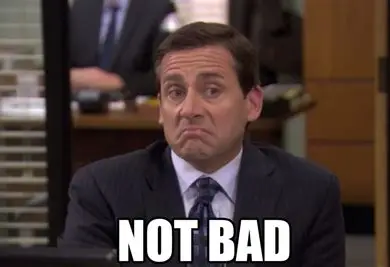